# РГР №1
## Численные методы алгебры  
## Чугуевский Роман и Образцов Алексей
**Группа:** J3113 
**Вариант:** 7  



## 1. Цель работы

Предложить среднеквадратическую аппроксимацию табличной функции многих переменных, проанализировать чувствительность точного решения к ошибкам округления, проверить сходимость расчётных и исходных данных.



## 2. Теоретические сведения

### 2.1 Линейная регрессия

Линейная регрессия - метод моделирования зависимости между зависимой переменной $y$ и независимыми переменными $X$:

$$y = X\mathbf{w} + \varepsilon$$

где $\mathbf{w}$ - вектор весов, $\varepsilon$ - случайная ошибка. Задача обучения - найти веса $\mathbf{w}$, минимизирующие среднеквадратичную ошибку:

$$\mathbf{w}^* = \arg\min_{\mathbf{w}} \|X\mathbf{w} - \mathbf{y}\|^2$$

Связь с МНК. Дифференцируя по $\mathbf{w}$ и приравнивая к нулю, получаем нормальную систему уравнений:

$$X^T X \mathbf{w} = X^T \mathbf{y}$$

При невырожденной матрице $X^T X$ единственное решение:

$$\mathbf{w}^* = (X^T X)^{-1} X^T \mathbf{y}$$

Таким образом, линейная регрессия сводится к решению СЛАУ методом наименьших квадратов. Устойчивость решения определяется числом обусловленности матрицы $X^T X$: чем оно больше, тем чувствительнее веса к малым возмущениям данных.

### 2.2 Предобработка данных

StandardScaler нормализует каждый признак: при `with_mean=True` вычитает среднее, при `with_std=True` делит на стандартное отклонение. Это приводит признаки к единому масштабу и уменьшает число обусловленности матрицы $X^T X$.

PolynomialFeatures генерирует полиномиальные признаки степени `degree`. Например, при `degree=2` и признаках $(x_1, x_2)$ добавляются $x_1^2,\ x_1 x_2,\ x_2^2$. На 8 исходных признаках `degree=2` даёт 44 столбца, `degree=3` — 164.

### 2.3 Метрика качества MAE

Средняя абсолютная ошибка (Mean Absolute Error):

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

Интерпретируется в единицах целевой переменной (доллары). Менее чувствительна к выбросам, чем MSE.

---

## 3. Ход работы

### 3.1 Описание датасета

Датасет `housing.csv` (California Housing, перепись США 1990 г.) содержит 20 640 записей о районах Калифорнии; после удаления пропусков остаётся 20 433 строки и 8 числовых признаков: координаты (`longitude`, `latitude`), медианный возраст домов, общее число комнат и спален, население, число домохозяйств и медианный доход. Целевая переменная — `median_house_value` (медианная стоимость дома, долл.): от 14 999 до 500 001, среднее ≈ 206 864. Разбиение train/test — 76/24 (`random_state=50`, вариант 7).

### Задание 1

Датасет: 20433 строк, 8 признаков
          longitude      latitude  housing_median_age   total_rooms  \
count  20433.000000  20433.000000        20433.000000  20433.000000   
mean    -119.570689     35.633221           28.633094   2636.504233   
std        2.003578      2.136348           12.591805   2185.269567   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1450.000000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.720000           37.000000   3143.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20433.000000  20433.000000   20433.000000   
mean       537.870553   1424.946949    499.433465       3.871162   
std        421.385070   1133.208490    382.299226       1.899291   
min          1.000000      3.000000      1.000000     

   with_mean  with_std  degree   MAE_train    MAE_test      cond
1      False     False       1  50584.5976  51408.9089  8.85e+06
2       True     False       1  50584.5976  51408.9089  2.37e+07
3      False      True       1  50584.5976  51408.9089  2.38e+05
4       True      True       1  50584.5976  51408.9089  2.46e+02
5       True      True       2  44855.4479  45996.0769  2.80e+05
6       True      True       3  41243.1378  43922.2513  3.12e+09


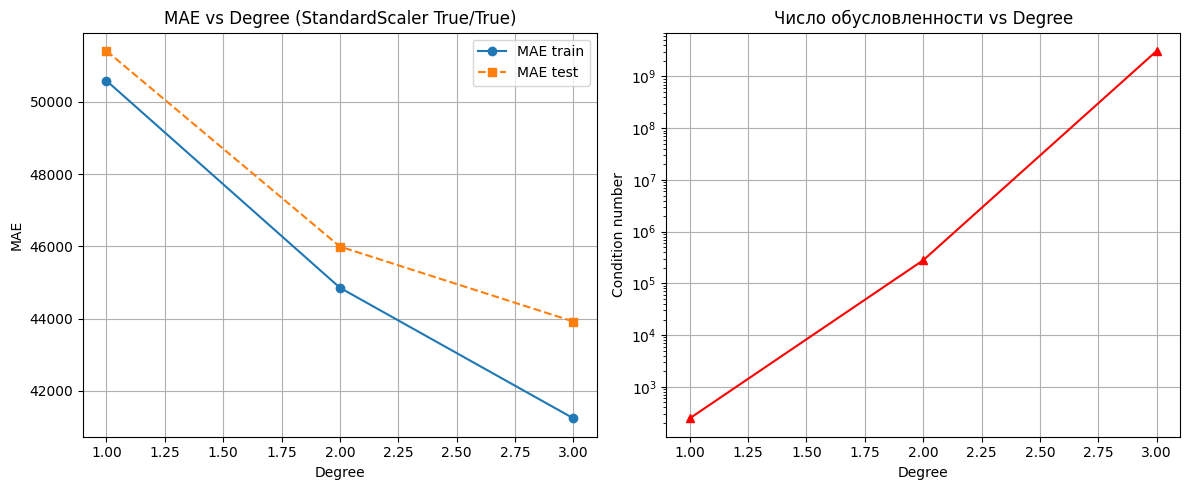

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv', sep=';')

df = df.dropna()

X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

print(f"Датасет: {df.shape[0]} строк, {X.shape[1]} признаков")
print(df.describe())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.24, random_state=50 #вариант 7
)

experiments = [
    (False, False, 1),
    (True,  False, 1),
    (False, True,  1),
    (True,  True,  1),
    (True,  True,  2),
    (True,  True,  3),
]

results = []

for with_mean, with_std, degree in experiments:
    pipe = Pipeline([
        ('scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('model',  LinearRegression())
    ])
    pipe.fit(X_train, y_train)

    mae_train = mean_absolute_error(y_train, pipe.predict(X_train))
    mae_test  = mean_absolute_error(y_test,  pipe.predict(X_test))

    # Число обусловленности X^T * X
    X_tr = pipe[:-1].transform(X_train)
    XtX  = X_tr.T @ X_tr
    cond = np.linalg.cond(XtX)

    results.append({
        'with_mean': with_mean,
        'with_std':  with_std,
        'degree':    degree,
        'MAE_train': round(mae_train, 4),
        'MAE_test':  round(mae_test,  4),
        'cond':      f'{cond:.2e}'
    })

res_df = pd.DataFrame(results)
res_df.index += 1
print(res_df.to_string())

tt = res_df[(res_df['with_mean'] == True) & (res_df['with_std'] == True)].copy()
tt['MAE_train'] = tt['MAE_train'].astype(float)
tt['MAE_test']  = tt['MAE_test'].astype(float)
tt['cond_val']  = tt['cond'].apply(lambda x: float(x))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(tt['degree'], tt['MAE_train'], 'o-', label='MAE train')
axes[0].plot(tt['degree'], tt['MAE_test'],  's--', label='MAE test')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs Degree (StandardScaler True/True)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(tt['degree'], tt['cond_val'], 'r^-')
axes[1].set_xlabel('Degree')
axes[1].set_ylabel('Condition number')
axes[1].set_title('Число обусловленности vs Degree')
axes[1].set_yscale('log')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('figures/results.png', dpi=150)
plt.show()

## 4. Анализ результатов

**Влияние масштабирования.**
При `degree=1` MAE одинакова при любом сочетании `with_mean`/`with_std`: 50 584.60 на train и 51 408.91 на test. Линейная модель со свободным членом инвариантна к аффинным преобразованиям признаков, поэтому масштабирование не меняет предсказаний. Зато число обусловленности $X^T X$ меняется сильно:

| Предобработка | cond($X^T X$) |
|---|---|
| без масштабирования | 8.85e+06 |
| только центрирование | 2.37e+07 |
| только деление на std | 2.38e+05 |
| полная стандартизация | 2.46e+02 |

Полная стандартизация снижает число обусловленности более чем на 4 порядка. Одно лишь центрирование его даже увеличивает: признаки остаются разномасштабными (`total_rooms` ~10³, `median_income` ~1), а основной вклад в плохую обусловленность даёт именно разброс масштабов.

**Влияние степени полинома.**
При `degree=2` MAE_test снижается до 45 996 (−10.5% к линейной модели), при `degree=3` — до 43 922 (−14.6%): модель улавливает нелинейные зависимости.

**Переобучение.**
Разрыв между MAE_train и MAE_test растёт с ростом степени: 824 → 1 141 → 2 679. Это признак начинающегося переобучения, но при 15.5 тыс. обучающих строк и 164 признаках модель ещё не запоминает данные: на тесте `degree=3` остаётся лучшей.

**Число обусловленности и качество модели.**
С ростом степени число обусловленности растёт на порядки: 2.46e+02 → 2.80e+05 → 3.12e+09. Полиномиальные признаки сильно коррелируют между собой, и при `degree=3` решение нормальной системы $X^T X \mathbf{w} = X^T \mathbf{y}$ в арифметике double теряет 9–10 из ~16 значащих цифр. На практике `sklearn.LinearRegression` решает задачу через `lstsq` (SVD), а не через нормальные уравнения, поэтому реальная потеря точности меньше — но для ручной реализации МНК это критично.

**Лучшая комбинация.**
Минимальную MAE_test (43 922) даёт `StandardScaler(True, True)` + `degree=3`. С учётом обусловленности более надёжный вариант — `degree=2` (MAE_test 45 996 при cond ≈ 3e+05) либо `degree=3` с регуляризацией (Ridge).

## 5. Выводы

Масштабирование признаков не влияет на точность линейной регрессии, но снижает число обусловленности $X^T X$ с 8.85e+06 до 2.46e+02 и делает решение МНК численно устойчивым. Полиномиальные признаки степени 2–3 улучшают MAE на тесте на 10–15%, но число обусловленности при этом растёт до 3e+09, а разрыв train/test — втрое. Компромисс между качеством и устойчивостью — стандартизация + `degree=2` или `degree=3` с регуляризацией.
